In [ ]:
# ruff: noqa
import os

os.sys.path.append("../../../..")

In [ ]:
from feedback_grape.utils.states import basis, coherent
N_cav = 20
basis_state = basis(n=2)
coherent_state = coherent(n=N_cav, alpha=3)

In [ ]:
from feedback_grape.utils.operators import create, destroy
number_operator = create(N_cav) @ destroy(N_cav)

In [ ]:
from feedback_grape.utils.tensor import tensor
ground_qubit = basis(n=2)
ground_cavity = basis(n=N_cav)
ground_state = tensor(ground_cavity, ground_qubit)

In [ ]:
import jax
import jax.numpy as jnp
from jax.scipy.linalg import expm
from feedback_grape.utils.operators import (
sigmap, sigmam, create, destroy, identity, cosm, sinm
)

In [ ]:
def meas_operator(measurement_outcome, params):
    gamma, delta = params
    cav_operator = (
    gamma * create(N_cav) @ destroy(N_cav)
    + delta / 2 * identity(N_cav)
    )
    angle = tensor(cav_operator, identity(2))
    meas_op = jnp.where(
    measurement_outcome == 1,
    cosm(angle),
    sinm(angle),
    )
    return meas_op

In [ ]:
def qubit_unitary(alphas):
    alpha_re, alpha_im = alphas
    alpha = alpha_re + 1j * alpha_im
    h_dt = (alpha*sigmap() + alpha.conjugate()*sigmam()) / 2
    return tensor(identity(N_cav), expm(-1j * h_dt))
    
def qubit_cavity_unitary(betas):
    beta_re, beta_im = betas
    beta = beta_re + 1j * beta_im
    a_sigp = tensor(destroy(N_cav), sigmap())
    adag_sigm = tensor(create(N_cav), sigmam())
    h_dt = (beta * a_sigp + beta.conjugate() * adag_sigm) / 2
    return expm(-1j * h_dt)

In [ ]:
from feedback_grape.fgrape import Gate

measure = Gate(
    gate=meas_operator,
    initial_params=[-3.32166965, -1.29192487],
    measurement_flag=True
)

In [ ]:
qub_unitary = Gate(
    gate=qubit_unitary,
    initial_params=[3.04255722, 0.59257698],
    measurement_flag=False
)
qub_cav = Gate(
    gate=qubit_cavity_unitary,
    initial_params=[-1.58503058, 2.06652483],
    measurement_flag=False
)

In [ ]:
n_average = 1
beta = jnp.log((1 / n_average) + 1)
diags = jnp.exp(-beta * jnp.arange(N_cav))
normalized_diags = diags / jnp.sum(diags, axis=0)
rho_cav0 = jnp.diag(normalized_diags)
rho_qub0 = basis(2, 0) @ basis(2, 0).conj().T
rho0 = tensor(rho_cav0, rho_qub0)

In [ ]:
from feedback_grape.utils.states import fock
psi_cav_target = (
    fock(N_cav, 1) + fock(N_cav, 2) + fock(N_cav, 3)
) / jnp.sqrt(3)
psi_qub_target = basis(2, 0)
psi_target = tensor(psi_cav_target, psi_qub_target)
rho_target = psi_target @ psi_target.conj().T

In [ ]:
system_params = [measure, qub_unitary, qub_cav]
num_time_steps = 5

In [ ]:
from feedback_grape.fgrape import optimize_pulse
result = optimize_pulse(
    init_state=rho0,
    target_state=rho_target,
    system_params=system_params,
    num_time_steps=num_time_steps,
    mode="lookup",
    goal="fidelity",
    max_iter=100,
    convergence_threshold=1e-6,
    learning_rate=0.02,
    evo_type="density",
    progress=True,
    batch_size=10,
    eval_time_steps=2*num_time_steps
)

Iteration 10, Loss: 0.619694, T=4s, eta=449s
Iteration 20, Loss: 0.559191, T=9s, eta=465s
Iteration 30, Loss: 0.654462, T=15s, eta=480s
Iteration 40, Loss: 0.690517, T=20s, eta=480s
Iteration 50, Loss: 0.606377, T=25s, eta=476s
Iteration 60, Loss: 0.688028, T=30s, eta=473s
Iteration 70, Loss: 0.736810, T=35s, eta=470s
Iteration 80, Loss: 0.865780, T=41s, eta=470s
Iteration 90, Loss: 0.895460, T=47s, eta=474s
Iteration 100, Loss: 1.038856, T=54s, eta=486s
Iteration 110, Loss: 1.158938, T=59s, eta=479s
Iteration 120, Loss: 1.002144, T=64s, eta=471s
Iteration 130, Loss: 0.755226, T=69s, eta=463s
Iteration 140, Loss: 0.877550, T=74s, eta=456s
Iteration 150, Loss: 1.289478, T=79s, eta=448s
Iteration 160, Loss: 0.713528, T=84s, eta=442s
Iteration 170, Loss: 1.031732, T=89s, eta=435s
Iteration 180, Loss: 1.096960, T=94s, eta=429s
Iteration 190, Loss: 1.128354, T=99s, eta=423s
Iteration 200, Loss: 0.994939, T=104s, eta=417s
Iteration 210, Loss: 1.328314, T=109s, eta=411s
Iteration 220, Loss: 1

In [ ]:
import matplotlib.pyplot as plt

# `result.reward_history` holds the reward (here the batch-mean fidelity, in
# [0, 1]) at every training iteration, as opposed to the printed loss which
# includes the unbounded log-probability REINFORCE term used for the gradient.
reward_history = getattr(result, "reward_history", None)
if reward_history is None:
    raise RuntimeError(
        "`result` has no reward history. It was produced by a version of "
        "feedback_grape.fgrape imported before `reward_history` was added to "
        "FgResult — restart the kernel and re-run the optimize_pulse cell."
    )
iters = jnp.arange(reward_history.shape[0])

# The reward is estimated over `batch_size` stochastic trajectories, so it is
# noisy; overlay a rolling mean to see the underlying trend.
window = 20
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(iters, reward_history, alpha=0.35, label="reward (per-iteration, batch mean)")
if reward_history.shape[0] >= window:
    smoothed = jnp.convolve(reward_history, jnp.ones(window) / window, mode="valid")
    ax.plot(iters[window - 1:], smoothed, color="C3", lw=2, label=f"rolling mean (window={window})")
ax.axhline(1.0, ls="--", color="gray", lw=1, label="max reward")
ax.set_xlabel("iteration")
ax.set_ylabel("reward (mean fidelity)")
ax.set_ylim(0, 1.05)
ax.set_title("Reward evolution during training")
ax.legend()
plt.show()

print(f"initial reward: {float(reward_history[0]):.4f}")
print(f"final reward:   {float(reward_history[-1]):.4f}")
print(f"best reward:    {float(jnp.nanmax(reward_history)):.4f}")

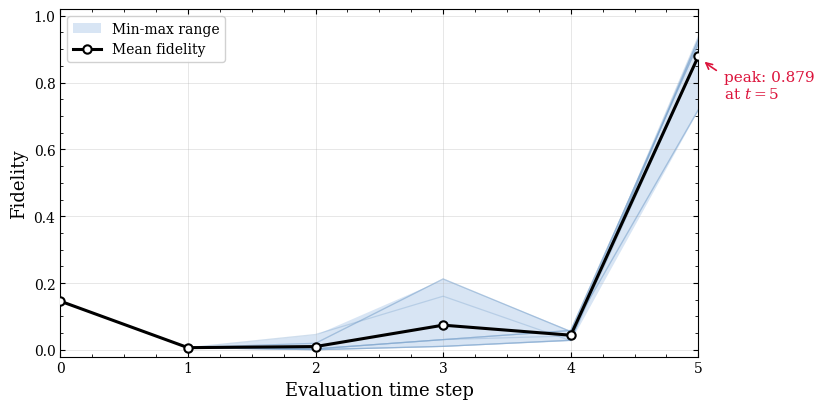

In [ ]:
# Fidelity vs. evaluation time step.
# `result.fidelity_each_timestep` is a list of length eval_time_steps + 1
# (index 0 = initial state); each entry holds the fidelity of every
# evaluation trajectory in the batch at that time step.
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import matplotlib.pyplot as plt
n_steps = 5  # only plot the initial state plus the first `n_steps` time steps
fid = jnp.stack(result.fidelity_each_timestep)[: n_steps + 1]  # (n_steps + 1, batch)
t = jnp.arange(fid.shape[0])

fid_mean = fid.mean(axis=1)
fid_min = fid.min(axis=1)
fid_max = fid.max(axis=1)

peak_idx = int(jnp.argmax(fid_mean))
peak_val = float(fid_mean[peak_idx])

with plt.rc_context({
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "axes.grid": True,
    "grid.alpha": 0.35,
    "grid.linewidth": 0.6,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
}):
    fig, ax = plt.subplots(figsize=(10, 4.2))

    # min-max envelope across the evaluation batch
    ax.fill_between(
        t, fid_min, fid_max,
        color="#a9c6e8", alpha=0.45, lw=0, label="Min-max range",
    )
    # individual trajectories, faint, inside the band
    ax.plot(t, fid, color="#7ba3cc", alpha=0.35, lw=0.9)
    # batch-mean fidelity
    ax.plot(
        t, fid_mean,
        color="black", lw=2.2, marker="o", ms=6,
        mfc="white", mec="black", mew=1.5, zorder=5,
        label="Mean fidelity",
    )

    # peak label placed outside the axes, arrow pointing in at the peak
    ax.annotate(
        f"peak: {peak_val:.3f}\nat $t = {peak_idx}$",
        xy=(peak_idx, peak_val),
        xytext=(1.04, 0.78), textcoords="axes fraction",
        color="crimson", fontsize=11, ha="left", va="center",
        annotation_clip=False,
        arrowprops=dict(arrowstyle="->", color="crimson", lw=1.2,
                        connectionstyle="arc3,rad=-0.2",
                        shrinkA=4, shrinkB=6, clip_on=False),
    )

    ax.set_xlabel("Evaluation time step", fontsize=13)
    ax.set_ylabel("Fidelity", fontsize=13)
    ax.set_xlim(t[0], t[-1])
    ax.set_ylim(-0.02, 1.02)
    # numbered major ticks plus unnumbered minor ticks on both axes
    ax.set_xticks(t)
    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.yaxis.set_major_locator(MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax.legend(loc="upper left", framealpha=0.9)
    # leave room on the right for the outside annotation
    fig.tight_layout(rect=(0, 0, 0.84, 1))
    fig.savefig("fidelity_vs_eval_time_step.pdf", bbox_inches="tight")
    plt.show()